# Validazione finale, feature importance e classificazione delle regioni critiche

Questa ultima fase rafforza il progetto in tre modi:

1. usa un **backtesting rolling** per non dipendere da un singolo split temporale;
2. mostra quali feature contano di piu nel modello ML;
3. trasforma la previsione numerica in una classificazione: regione critica oppure no.

La classificazione e utile per una lettura da policy, perche spesso un decisore deve sapere prima dove intervenire, non solo il valore puntuale previsto.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import modeling, utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Preparazione campioni

In [2]:
samples = {
    "unemployment_rate": utils.build_forecasting_sample("unemployment_rate"),
    "employed_thousands": utils.build_forecasting_sample("employed_thousands"),
}

pd.DataFrame(
    [
        {
            "target": target,
            "rows": len(sample),
            "territories": sample["REF_AREA"].nunique(),
            "year_min": int(sample["year"].min()),
            "year_max": int(sample["year"].max()),
        }
        for target, sample in samples.items()
    ]
)

,target,rows,territories,year_min,year_max
0,unemployment_rate,147,21,2019,2025
1,employed_thousands,147,21,2019,2025


## 2. Backtesting rolling

Usiamo finestre espandenti:

- train fino al 2021, test 2022-2025;
- train fino al 2022, test 2023-2025;
- train fino al 2023, test 2024-2025.

Questo rende il confronto piu robusto rispetto a un solo split.

In [3]:
backtest_metrics, backtest_predictions = modeling.rolling_backtest(samples, train_end_years=[2021, 2022, 2023])
backtest_summary = modeling.summarize_backtest_metrics(backtest_metrics)

backtest_metrics.to_csv(PROCESSED_DIR / "rolling_backtest_metrics.csv", index=False)
backtest_predictions.to_csv(PROCESSED_DIR / "rolling_backtest_predictions.csv", index=False)
backtest_summary.to_csv(PROCESSED_DIR / "rolling_backtest_summary.csv", index=False)

backtest_summary

,target,model,MAE_mean,MAE_std,RMSE_mean,MAPE_mean,R2_mean,windows
0,employed_thousands,Naive lag-1,15.412806,2.729308,24.401755,1.402450,0.999423,3
1,employed_thousands,Gradient Boosting,31.001039,1.696583,48.882885,3.926313,0.997733,3
2,employed_thousands,Ridge ML lineare,34.778829,2.486454,43.799308,8.101138,0.998162,3
3,employed_thousands,ElasticNet ML lineare,35.842666,1.915756,45.486164,8.065294,0.998033,3
4,employed_thousands,OLS classica,90.641725,83.016499,105.136949,20.191906,0.984682,3
5,employed_thousands,Random Forest,101.374988,43.847273,194.461734,9.105745,0.958724,3
6,unemployment_rate,Random Forest,0.795768,0.132750,1.044857,15.637681,0.921965,3
7,unemployment_rate,Gradient Boosting,0.829635,0.083927,1.074329,14.866966,0.918054,3
8,unemployment_rate,Naive lag-1,0.946552,0.062866,1.206850,14.498604,0.894907,3
9,unemployment_rate,ElasticNet ML lineare,1.125442,0.575681,1.318884,22.075796,0.862266,3


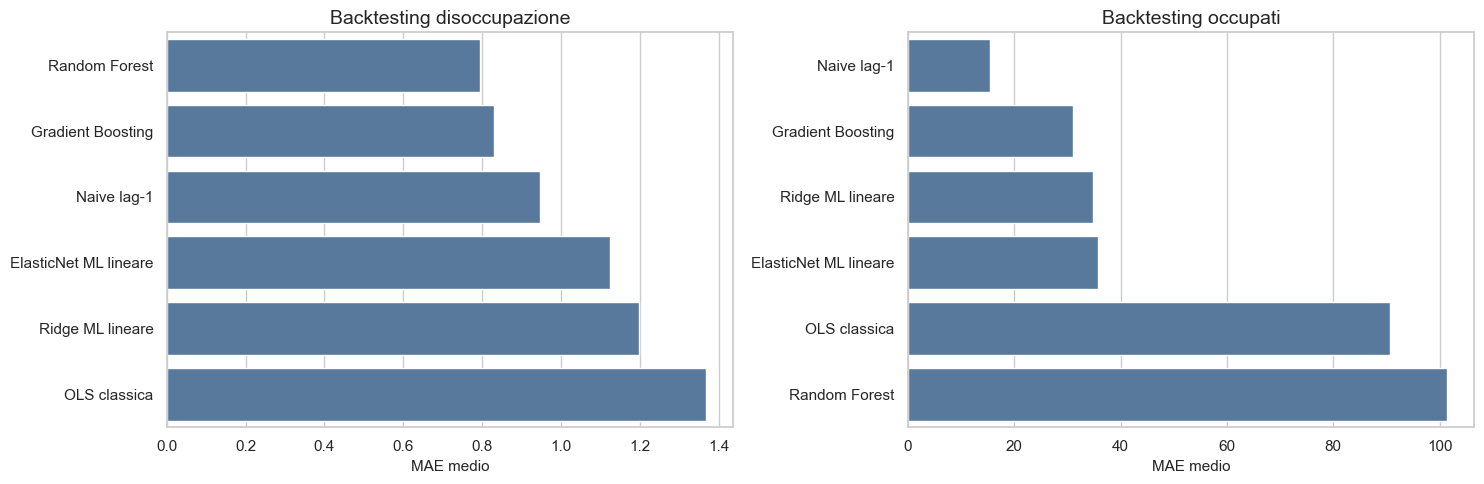

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, target, title in zip(
    axes,
    ["unemployment_rate", "employed_thousands"],
    ["Backtesting disoccupazione", "Backtesting occupati"],
):
    subset = backtest_summary.query("target == @target").sort_values("MAE_mean")
    sns.barplot(data=subset, x="MAE_mean", y="model", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("MAE medio")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "rolling_backtest_mae.png", dpi=150)
plt.show()

**Lettura:** se un modello resta buono su piu finestre temporali, e piu credibile. Nel nostro caso, per la disoccupazione i modelli non lineari restano in testa; per gli occupati resta fortissima la baseline dell'anno precedente.

## 3. Feature importance del Random Forest sulla disoccupazione

In [5]:
importance = modeling.fitted_random_forest_importance(
    samples["unemployment_rate"],
    target="unemployment_rate",
    train_end_year=2023,
)
importance.to_csv(PROCESSED_DIR / "rf_feature_importance_unemployment.csv", index=False)
feature_labels = {
    "unemployment_rate_lag1": "Disoccupazione anno precedente",
    "neet_rate_lag1": "NEET anno precedente",
    "gdp_per_employed_lag1": "PIL per occupato anno precedente",
    "year": "Trend temporale",
    "log_gdp_lag1": "Log PIL anno precedente",
    "employed_thousands_lag1": "Occupati anno precedente",
    "territory_dummies": "Effetto territorio",
}
importance_display = importance.assign(
    feature_label=importance["feature_group"].map(feature_labels).fillna(importance["feature_group"])
)
importance_display

,feature_group,importance,feature_label
0,unemployment_rate_lag1,0.931979,Disoccupazione anno precedente
1,neet_rate_lag1,0.054162,NEET anno precedente
2,gdp_per_employed_lag1,0.007223,PIL per occupato anno precedente
3,year,0.002907,Trend temporale
4,log_gdp_lag1,0.001448,Log PIL anno precedente
5,employed_thousands_lag1,0.001278,Occupati anno precedente
6,territory_dummies,0.001003,Effetto territorio


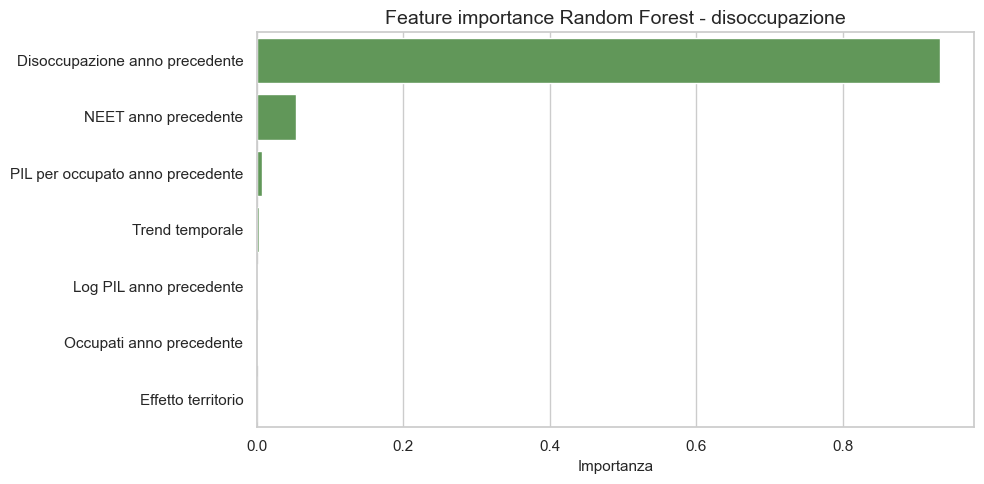

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=importance_display, x="importance", y="feature_label", ax=ax, color="#59A14F")
ax.set_title("Feature importance Random Forest - disoccupazione")
ax.set_xlabel("Importanza")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "rf_feature_importance_unemployment.png", dpi=150)
plt.show()

**Lettura:** la disoccupazione dell'anno precedente e il driver principale. Questo e coerente con un fenomeno persistente. Il NEET aggiunge informazione sociale importante. Il PIL per occupato pesa meno nella pura previsione puntuale, ma resta centrale per interpretare la qualita economica del territorio e definire gli interventi.

## 4. Classificazione delle regioni critiche

Definiamo una regione critica se il suo tasso di disoccupazione e sopra la mediana delle regioni nello stesso anno. Questo rende il problema piu vicino alla decisione pubblica: identificare aree da monitorare o finanziare con priorita.

In [7]:
class_metrics, class_predictions = modeling.fit_critical_classifiers(
    samples["unemployment_rate"],
    train_end_year=2023,
)
class_metrics.to_csv(PROCESSED_DIR / "critical_region_classification_metrics.csv", index=False)
class_predictions.to_csv(PROCESSED_DIR / "critical_region_predictions.csv", index=False)
class_metrics

,model,n_test,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,42,0.928571,1.0,0.85,0.918919,0.970455
1,Random Forest Classifier,42,0.761905,1.0,0.50,0.666667,0.959091


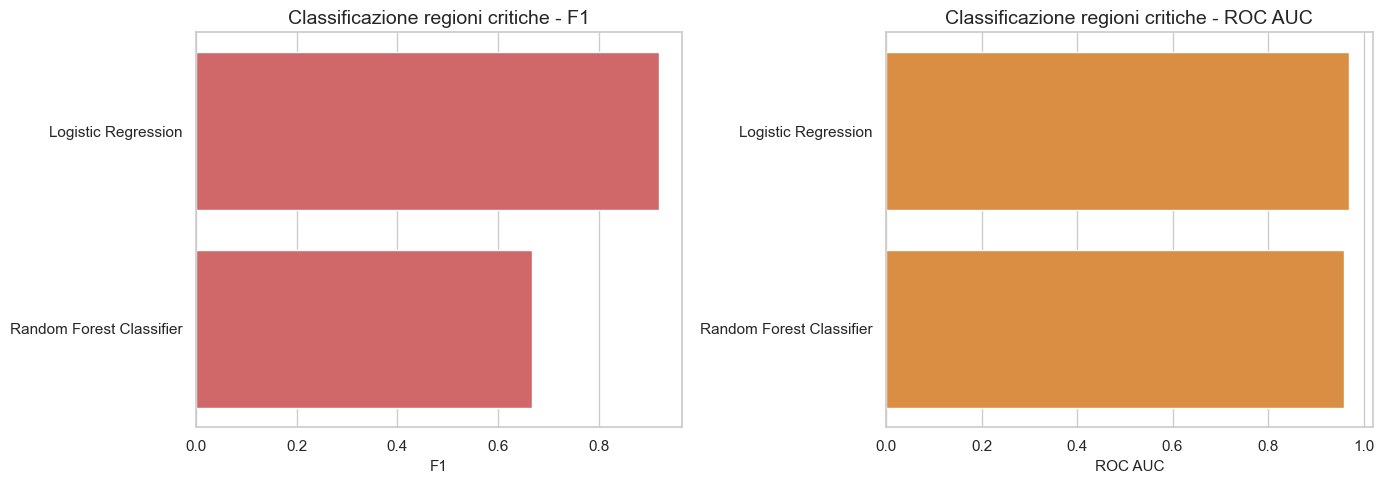

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=class_metrics, x="F1", y="model", ax=axes[0], color="#E15759")
axes[0].set_title("Classificazione regioni critiche - F1")
axes[0].set_xlabel("F1")
axes[0].set_ylabel("")

sns.barplot(data=class_metrics, x="ROC_AUC", y="model", ax=axes[1], color="#F28E2B")
axes[1].set_title("Classificazione regioni critiche - ROC AUC")
axes[1].set_xlabel("ROC AUC")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "critical_classification_metrics.png", dpi=150)
plt.show()

In [9]:
best_classifier = class_metrics.sort_values("F1", ascending=False).iloc[0]["model"]
critical_2025 = (
    class_predictions.query("year == 2025 and model == @best_classifier")
    .sort_values("critical_probability", ascending=False)
    .reset_index(drop=True)
)
critical_2025.head(10)

,Territorio,REF_AREA,year,model,actual_critical,predicted_critical,critical_probability,actual_unemployment_rate
0,Campania,ITF3,2025,Logistic Regression,1,1,0.996341,14.251343
1,Calabria,ITF6,2025,Logistic Regression,1,1,0.994050,10.210476
2,Sicilia,ITG1,2025,Logistic Regression,1,1,0.990817,12.477971
3,Puglia,ITF4,2025,Logistic Regression,1,1,0.865064,10.273240
4,Molise,ITF2,2025,Logistic Regression,1,1,0.742267,6.356495
5,Abruzzo,ITF1,2025,Logistic Regression,1,1,0.715292,6.762283
6,Sardegna,ITG2,2025,Logistic Regression,1,1,0.692924,9.532401
7,Basilicata,ITF5,2025,Logistic Regression,1,1,0.609310,5.510016
8,Lazio,ITE4,2025,Logistic Regression,1,1,0.500500,5.680821
9,Liguria,ITC3,2025,Logistic Regression,0,0,0.393049,4.710665


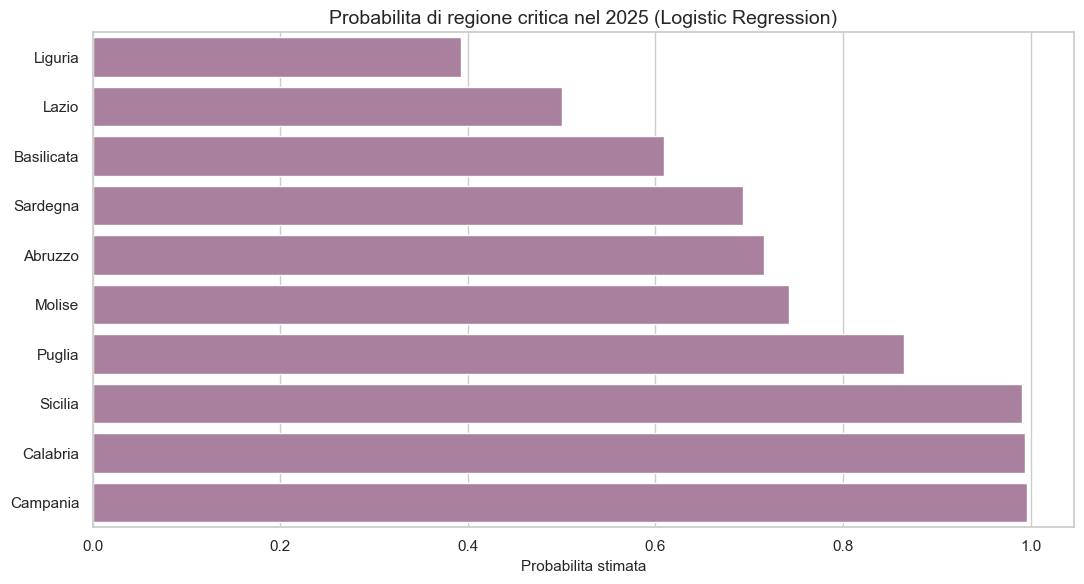

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
top_critical = critical_2025.head(10).sort_values("critical_probability")
sns.barplot(data=top_critical, x="critical_probability", y="Territorio", ax=ax, color="#B07AA1")
ax.set_title(f"Probabilita di regione critica nel 2025 ({best_classifier})")
ax.set_xlabel("Probabilita stimata")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "critical_region_probability_2025.png", dpi=150)
plt.show()

## 5. Conclusione finale pronta per la presentazione

In [11]:
best_unemployment = (
    backtest_summary.query("target == 'unemployment_rate'")
    .sort_values("MAE_mean")
    .iloc[0]
)
best_employment = (
    backtest_summary.query("target == 'employed_thousands'")
    .sort_values("MAE_mean")
    .iloc[0]
)
critical_regions = critical_2025.head(5)["Territorio"].tolist()

conclusion = f"""
Conclusione:

Il backtesting conferma che la disoccupazione regionale e prevista meglio da modelli ML non lineari,
in particolare {best_unemployment['model']}, con MAE medio pari a {best_unemployment['MAE_mean']:.2f}
punti percentuali. Questo suggerisce che la relazione tra territorio, NEET, PIL per occupato e
disoccupazione non e puramente lineare.

Per gli occupati, invece, il modello migliore e {best_employment['model']}. Questo significa che
l'occupazione regionale e molto persistente: l'informazione piu forte e il livello dell'anno precedente.

La classificazione delle regioni critiche indica come aree piu rilevanti: {', '.join(critical_regions)}.
Queste regioni vanno lette insieme alla tabella policy: se alta disoccupazione prevista si combina con
PIL per occupato basso e NEET elevato, la risposta non puo essere solo assistenziale. Serve una politica
integrata: investimenti produttivi, formazione tecnica, ITS/apprendistato, rafforzamento dei centri per
l'impiego e monitoraggio annuale di PIL per occupato e NEET.
"""
print(conclusion)


Conclusione:

Il backtesting conferma che la disoccupazione regionale e prevista meglio da modelli ML non lineari,
in particolare Random Forest, con MAE medio pari a 0.80
punti percentuali. Questo suggerisce che la relazione tra territorio, NEET, PIL per occupato e
disoccupazione non e puramente lineare.

Per gli occupati, invece, il modello migliore e Naive lag-1. Questo significa che
l'occupazione regionale e molto persistente: l'informazione piu forte e il livello dell'anno precedente.

La classificazione delle regioni critiche indica come aree piu rilevanti: Campania, Calabria, Sicilia, Puglia, Molise.
Queste regioni vanno lette insieme alla tabella policy: se alta disoccupazione prevista si combina con
PIL per occupato basso e NEET elevato, la risposta non puo essere solo assistenziale. Serve una politica
integrata: investimenti produttivi, formazione tecnica, ITS/apprendistato, rafforzamento dei centri per
l'impiego e monitoraggio annuale di PIL per occupato e NEET.

